In [1]:
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from estimation_fct import *
from graph_format import *

# Load model
from model import ModelClass

model = ModelClass() 

par = model.par
sol = model.sol
sim = model.sim


In [2]:
wealth = pd.read_csv("Data_cohort/wealth.csv").iloc[:, 1] # 34 - 75 
extensive = pd.read_csv("Data_cohort/extensive.csv").iloc[:, 1][:45-9] # 38 - 78
intensive = pd.read_csv("Data_cohort/intensive.csv").iloc[:, 1][:40-27] # 56 - 78

In [3]:
# means_string = "Data ny def/mean_matrix.csv"
# covariance_string = "Data ny def/variance_matrix.csv"

# variables = ["extensive_v2", "formue_plsats", "yearly_hours"]

# mean, variance_diag = load_and_process_data(means_string, covariance_string, par, variables)

mean = np.concatenate([extensive, wealth, intensive])

# Generate a variance matrix with the same length as the extended series but with the mean of the series
variance_cut = np.concatenate([np.full(len(extensive), np.nanmean(extensive)**2), 
                               np.full(len(wealth), np.nanmean(wealth)**2), 
                               np.full(len(intensive), np.nanmean(intensive)**2)])



diag_inv = 1 / variance_cut
weight = np.diag(diag_inv)

In [ ]:
def randomize_theta_init(theta_init, bounds, pct=0.5):
    randomized = []
    for val, (lower, upper) in zip(theta_init, bounds):
        delta = pct * val
        min_val = max(lower, val - delta)
        max_val = min(upper, val + delta)
        randomized_val = np.random.uniform(min_val, max_val)
        randomized.append(randomized_val)
    return np.array(randomized)

# Prepare SMM
theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")

theta_init = np.array([1.3057835961, 2.1155312015, 7.2479715444, 1.0319540295, 0.0116026168, 4.8036019349])

# Original bounds
orig_bounds = [(0.1, 6.0),   # sigma
               (0.1, 10.0),  # gamma
               (0.0, 20.0),  # mu
               (0.0, 15.0),  # zeta
               (0.0, 0.3),  # gamma_1
               (0.01, 10.0)   # gamma_2
               ] 

theta_init_scaled = scale_params(theta_init, orig_bounds)

theta_random = randomize_theta_init(theta_init, orig_bounds)
theta_random_scaled = scale_params(theta_random, orig_bounds)

# Do SMM
objective = lambda theta: obj_func(theta, theta_names, mean, weight, model, orig_bounds, do_print=True)

res = minimize(
    objective, 
    theta_init_scaled,
    method='nelder-mead',
    bounds=[(0,1)] * len(theta_init_scaled),
    tol=1e-6,
    options={"maxiter":2000}
)

theta_final = unscale_params(res.x, orig_bounds)

print(theta_final)

1.3057835961, 2.1155312015, 7.2479715444, 1.0319540295, 0.0116026168, 4.8036019349, 
Error = 17.50287, x = [0.7836132 1.       ], Time = 386.7 seconds
1.3660727759, 2.1155312015, 7.2479715444, 1.0319540295, 0.0116026168, 4.8036019349, 


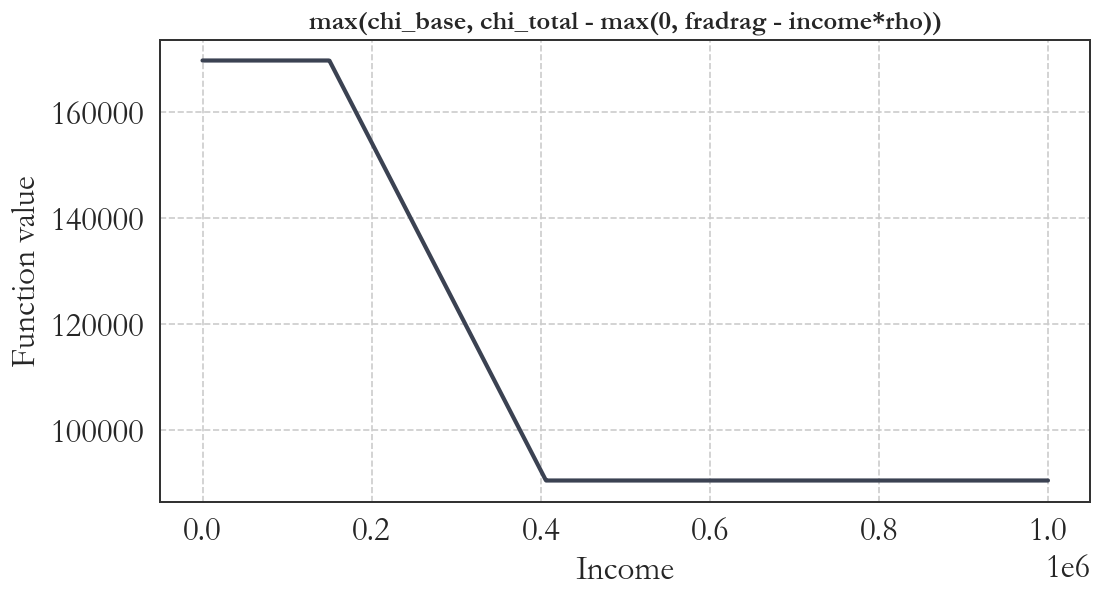

In [9]:
# Income grid
income = np.linspace(0, 1000000, 1000)

# Function definition
value = np.maximum(par.chi_base, par.chi_total - np.maximum(0, income - par.fradrag ) * par.rho )

# Plot (single plot, no specific colors)
plt.figure()
plt.plot(income, value)
plt.xlabel("Income")
plt.ylabel("Function value")
plt.title("max(chi_base, chi_total - max(0, fradrag - income*rho))")
plt.show()

1 NVFI
1 Fixed
0 NVFI
0 Fixed
2.7139320772735944


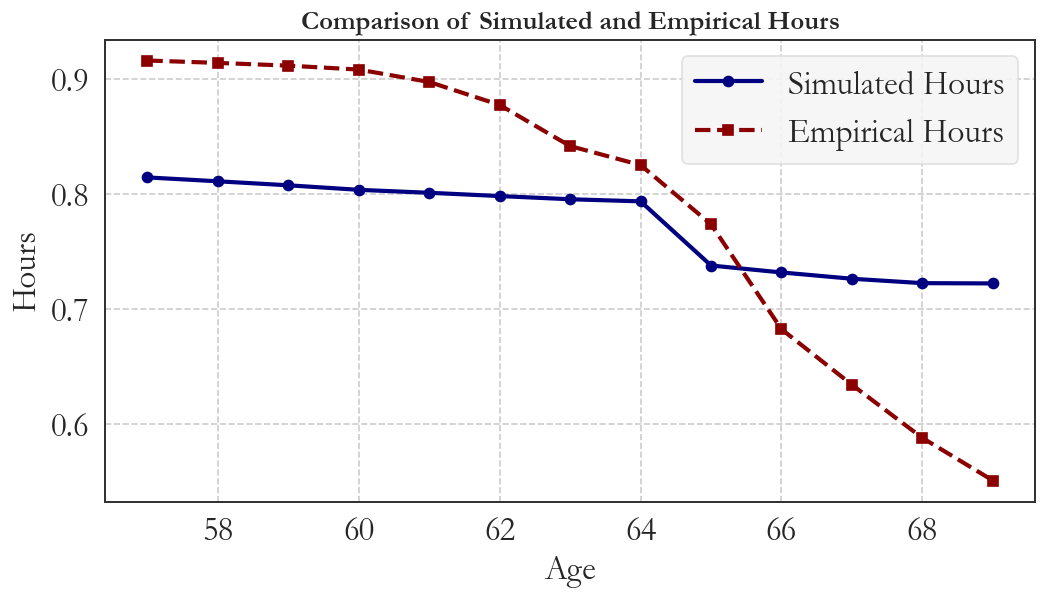

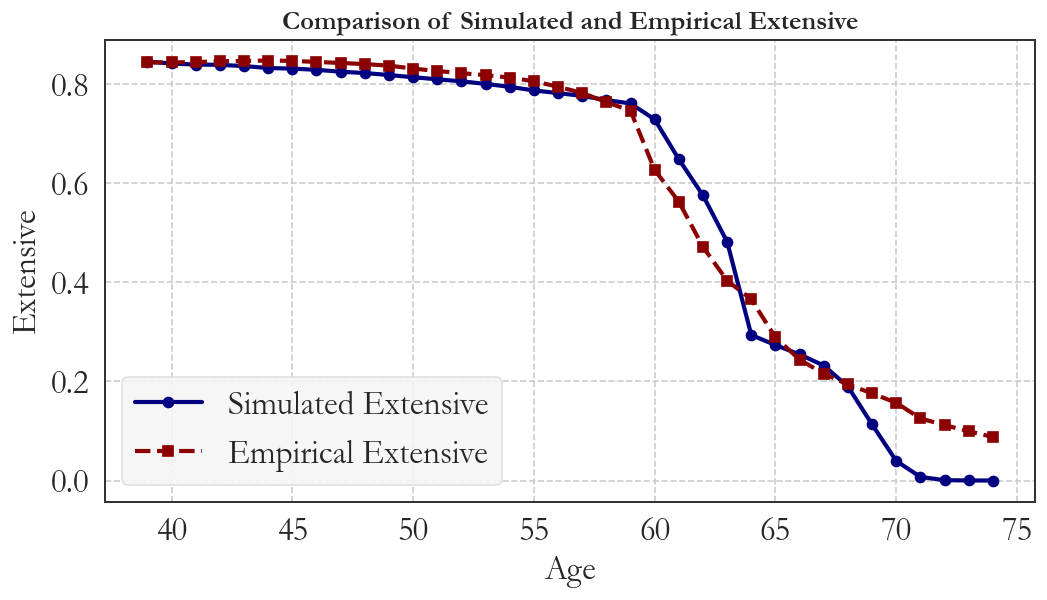

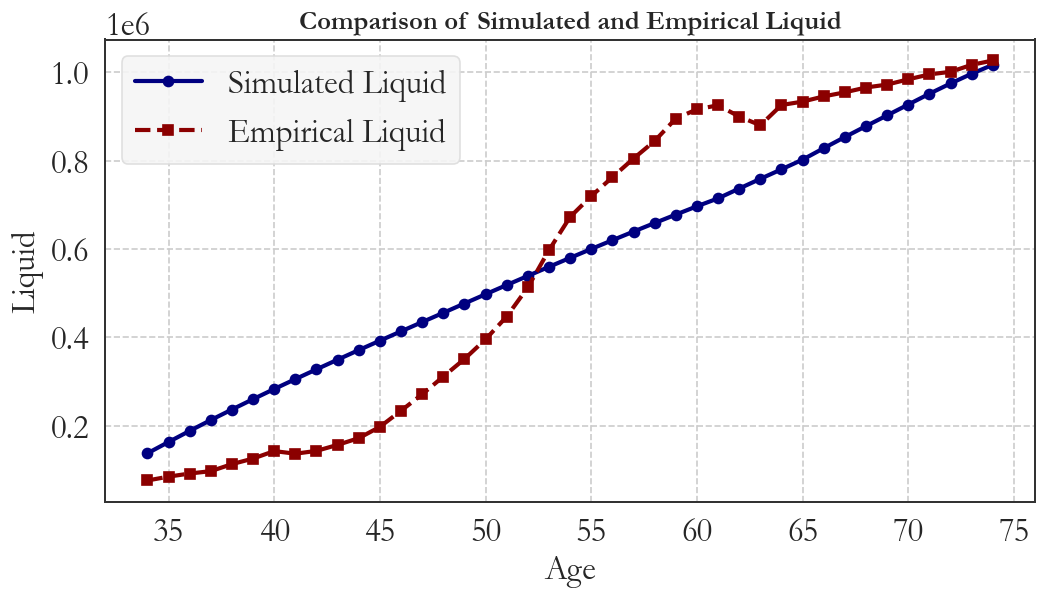

In [101]:
# Load the model with calibrated values
theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")
# # theta_names = ("beta", "zeta")

# theta_final = unscale_params(res.x, orig_bounds)

theta_final = np.array([1.3057835961, 2.1155312015, 7.2479715444, 1.0319540295, 0.0116026168, 4.8036019349])

for i, name in enumerate(theta_names):
    setattr(model.par, name, theta_final[i])

efterloen_options = [1, 0]
flexible_hours_options = ["NVFI", "Fixed"]

sim_means = []

for efterloen in efterloen_options:
    for flexible_hours in flexible_hours_options:

        print(efterloen, flexible_hours)

        par.efter = efterloen
        par.flexible_hours = flexible_hours

        model.solve()
        model.simulate()

        sim_mean = [
            np.nan_to_num(np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:45], nan=0.0),
            np.mean(model.sim.ex, axis=0)[:45],
            np.mean(model.sim.a, axis=0),
            np.clip(np.mean(model.sim.s, axis=0), 0, None)
        ]

        sim_means.append(sim_mean)

def loss_fn(params):
    hours_mean, extensive_mean, liquid_mean, _ = calc_means(sim_means, params)

    mom_sim = np.concatenate([extensive_mean[9:45], liquid_mean[4:45], hours_mean[27:40]])

    mom_data = mean

    return (mom_data - mom_sim).T @ weight @ (mom_data - mom_sim)

def calc_means(sim_means, params):
    efterloen_share = params[0]
    flexible_share = params[1]

    p11 = efterloen_share * flexible_share
    p10 = efterloen_share * (1 - flexible_share)
    p01 = (1 - efterloen_share) * flexible_share
    p00 = (1 - efterloen_share) * (1 - flexible_share)

    hours_mean              = p11*sim_means[0][0] + p10*sim_means[1][0] + p01*sim_means[2][0] + p00*sim_means[3][0]
    extensive_mean          = p11*sim_means[0][1] + p10*sim_means[1][1] + p01*sim_means[2][1] + p00*sim_means[3][1]
    liquid_mean             = p11*sim_means[0][2] + p10*sim_means[1][2] + p01*sim_means[2][2] + p00*sim_means[3][2]
    illiquid_mean           = p11*sim_means[0][3] + p10*sim_means[1][3] + p01*sim_means[2][3] + p00*sim_means[3][3]

    return hours_mean, extensive_mean, liquid_mean, illiquid_mean

x0 = np.array([0.55, 0.2])
bounds = [(0.0, 1.0), (0.0, 1.0)]

res = minimize(loss_fn, x0, method='L-BFGS-B', bounds=bounds,
               options={'ftol':1e-12, 'gtol':1e-8, 'maxiter':200})

print(res.fun)

test_params = np.array([1, 1])

hours_mean, extensive_mean, liquid_mean, illiquid_mean = calc_means(sim_means, res.x)

# plot the graph with calibrated values 
a_dict = {
    'hours': [hours_mean[27:40], intensive, 27],
    'extensive': [extensive_mean[9:45], extensive, 9],
    # 'illiquid': [illiquid_mean, moments['savings']],
    'liquid': [liquid_mean[4:45], wealth, 4]
}



# Define colors
simulated_color = "navy"  # Dark blue
empirical_color = "darkred"  # Dark red
ci_color = "lightcoral"  # Light red for confidence bands

for key, (simulated, empirical, extra_age) in a_dict.items():
    plt.figure(figsize=(10, 5))
    
    x_vals = np.arange(len(empirical)) + par.start_age + extra_age
    
    plt.plot(x_vals, simulated, label=f"Simulated {key.capitalize()}", marker="o", color=simulated_color)
    plt.plot(x_vals, empirical, label=f"Empirical {key.capitalize()}", linestyle="--", marker="s", color=empirical_color)

    # # 99.9% confidence interval
    # ci = std_dev
    # plt.fill_between(x_vals, empirical - ci, empirical + ci, color=ci_color, alpha=0.4, label="Empirical Standard Deviation")

    plt.xlabel("Age")
    plt.ylabel(key.capitalize())
    plt.title(f"Comparison of Simulated and Empirical {key.capitalize()}")
    plt.legend()
    plt.grid(True)
    plt.show()



In [15]:
par.flexible_hours = "NVFI"
par.efter = 1

model.solve()
model.simulate()

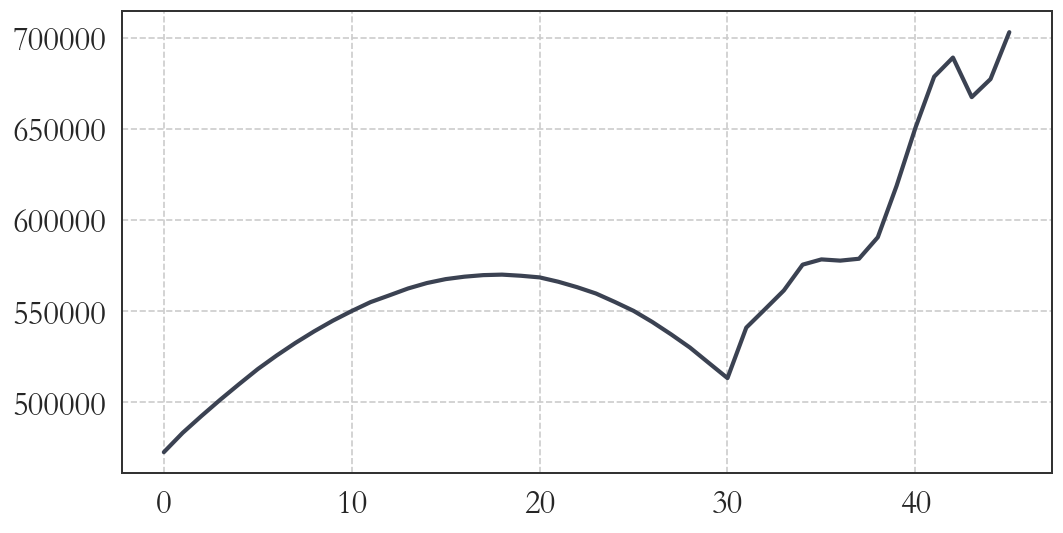

In [25]:
plt.plot(np.nanmean(np.where(model.sim.ex == 1, model.sim.w, np.nan), axis=0))

In [17]:
i = 6

par.k_m_grid[i, :, i, 1]

array([ 0.        ,  0.90171071,  1.8902032 ,  2.98101734,  4.19401059,
        5.55507023,  7.09875265,  8.87251864, 10.9438707 , 13.41313495,
       16.4382094 , 20.28774517, 25.47364969, 33.16727051, 47.23449551])

In [30]:
hours_mean

array([0.84699617, 0.84692365, 0.84718836, 0.84723473, 0.84680186,
       0.84560637, 0.84408199, 0.84159272, 0.84054133, 0.83845081,
       0.83454098, 0.83171763, 0.82952751, 0.829805  , 0.83084057,
       0.83185565, 0.83243485, 0.83285206, 0.83313127, 0.83304747,
       0.83280437, 0.83202293, 0.83073233, 0.82876901, 0.82561213,
       0.8214936 , 0.81614889, 0.80955481, 0.80182653, 0.79332266,
       0.78294283, 0.77952186, 0.77130533, 0.76434836, 0.75709263,
       0.652253  , 0.63736203, 0.62264536, 0.62407816, 0.61782023,
       0.62361862, 0.63295813, 0.63922527, 0.64230857,        nan])

In [7]:
# prepare your data dict
a_dict = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:55],
              moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:55],
                  moments['extensive']],
    'liquid': [np.mean(model.sim.a, axis=0),
               moments['assets']]
}


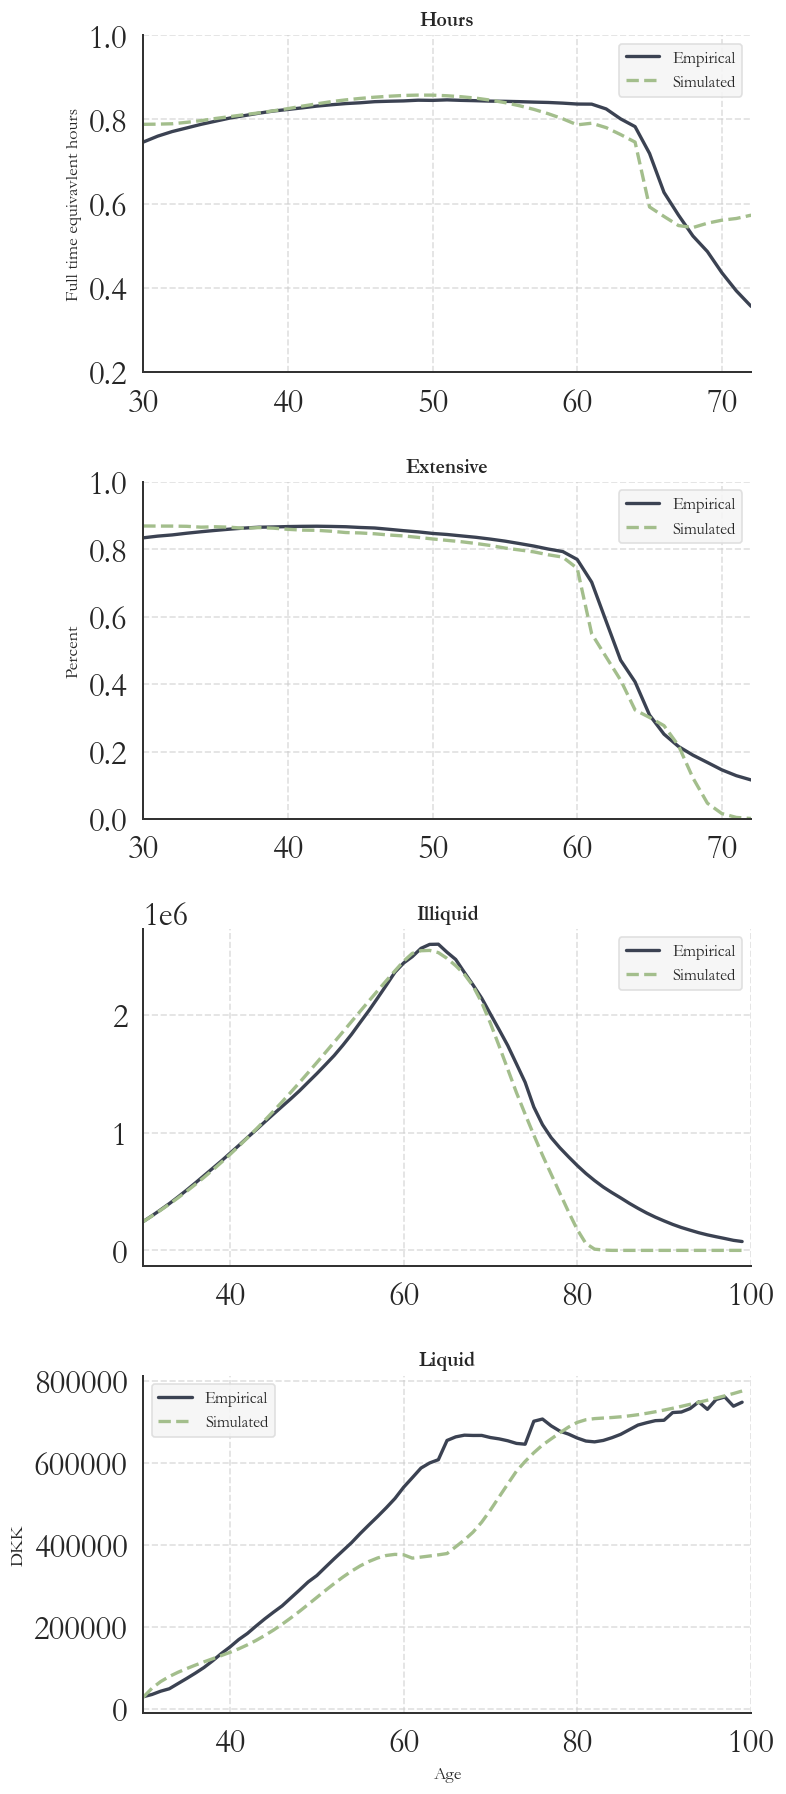

In [10]:
plot_model_vs_data_grid(a_dict, title="", save_title="in_sample_fit.png")


In [9]:
means_data = pd.read_csv("Data/mean_matrix.csv")

b_dict = {
    'illiquid': [np.clip(np.clip(np.mean(model.sim.s, axis=0), 0, None) / 1_000_000, 0, None),
                 moments['savings'] / 1_000_000]  ,
    'wages':    [np.nanmean(np.where(model.sim.ex==1, model.sim.w, np.nan)[:, :31] , axis=0),
                 means_data[means_data["alder"] <= 60]["hourly_salary_plsats_Mean"].to_numpy() * 1924]
        }

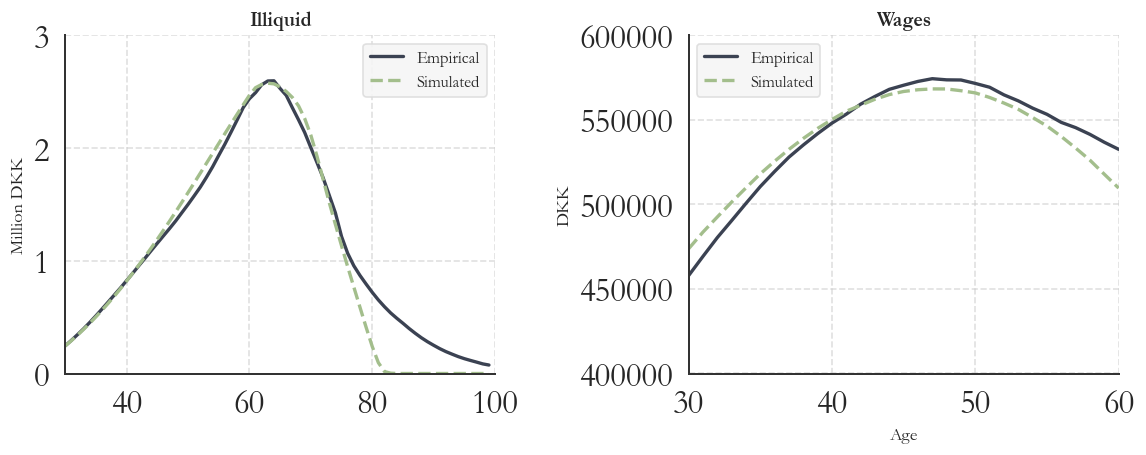

In [10]:
plot_model_vs_data_grid_oos(b_dict, title="", save_title="out_of_sample_fit.png")


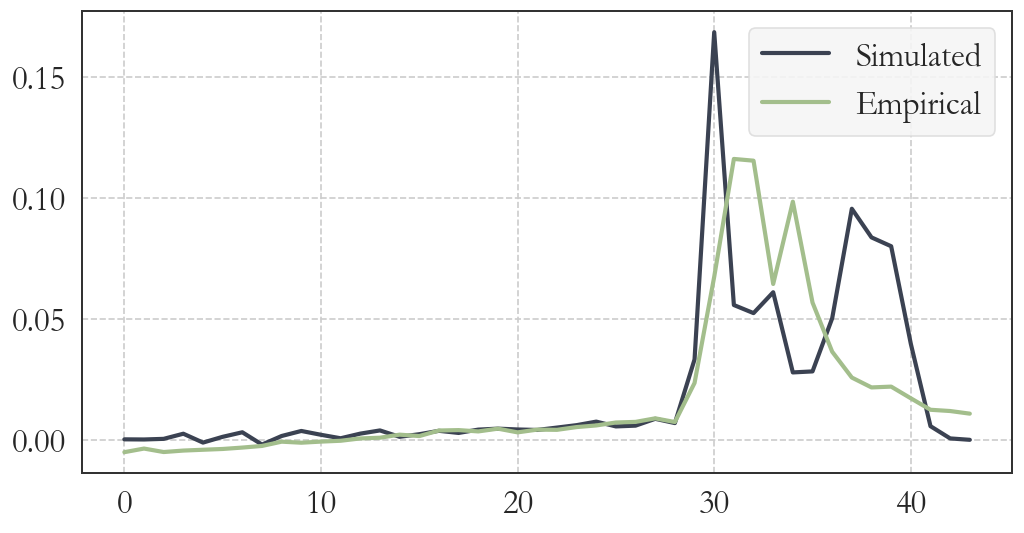

In [12]:
#take first differences of this np.mean(model.sim.ex, axis=0)[:45]

diff_ex_sim = -np.diff(np.mean(model.sim.ex, axis=0)[:45], axis=0)
diff_ex_moments = -np.diff(moments['extensive'][:45], axis=0)
plt.plot(diff_ex_sim, label='Simulated')
plt.plot(diff_ex_moments, label='Empirical')
plt.legend()
plt.show()

(0.0, 250000.0)

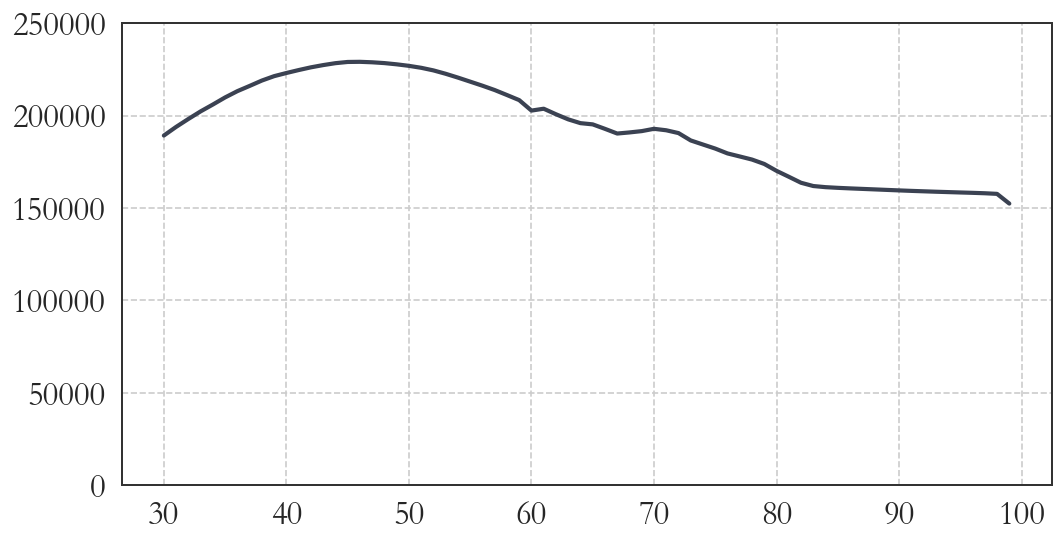

In [13]:
mask = model.sim.a > 0
c_filtered_mean = np.nanmean(np.where(mask, model.sim.c, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
plt.ylim(0, 250000)

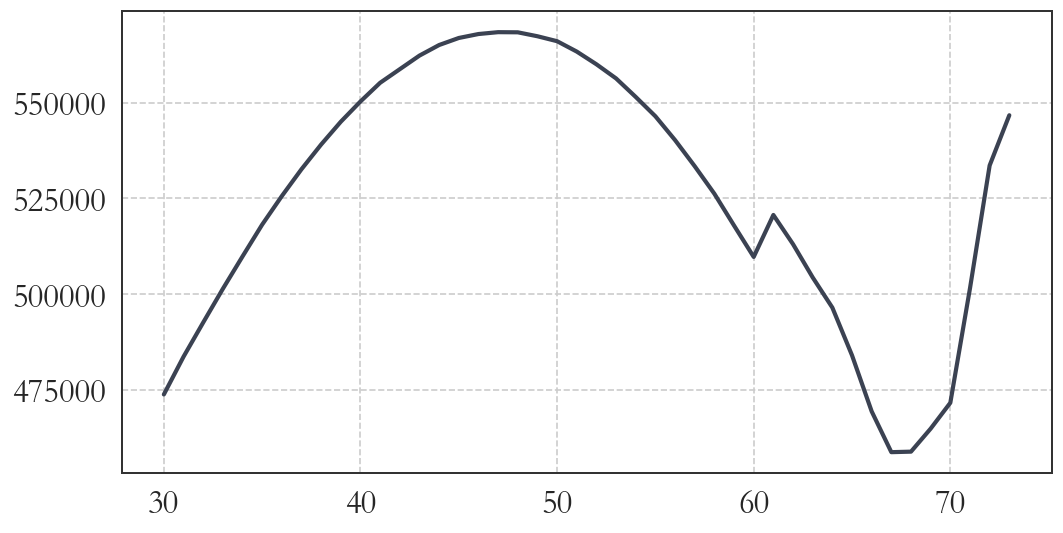

In [14]:
mask = model.sim.ex == 1
c_filtered_mean = np.nanmean(np.where(mask, model.sim.w, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
# plt.ylim(0, 250000)

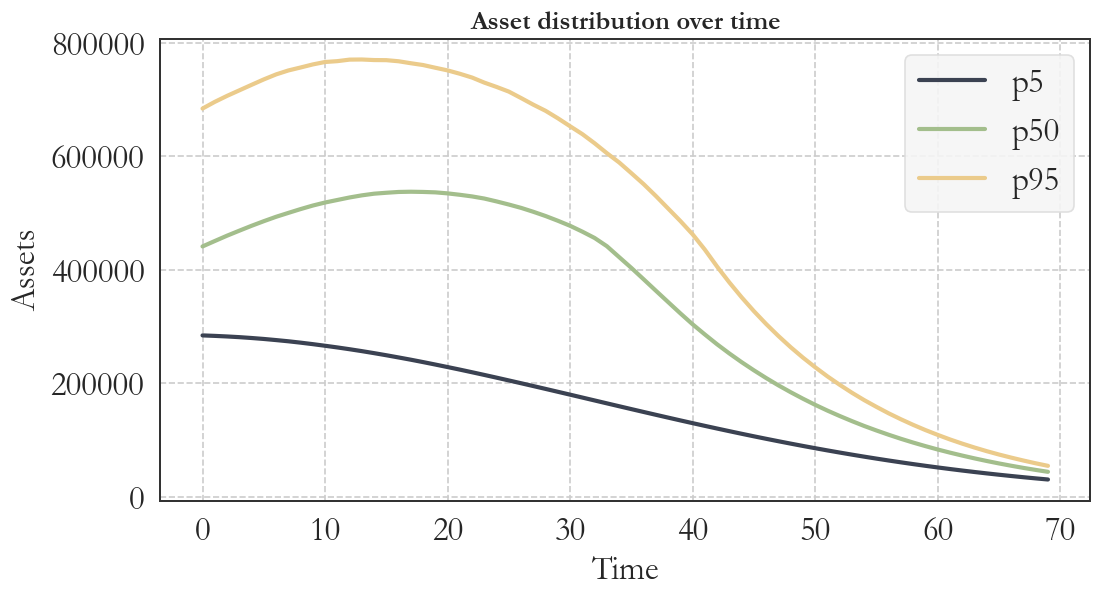

In [15]:
import numpy as np

w = model.sim.w
p5_w = np.percentile(w, 5, axis=0)
p50_w = np.percentile(w, 50, axis=0)
p95_w = np.percentile(w, 95, axis=0)

plt.figure()
plt.plot(p5_w, label='p5')
plt.plot(p50_w, label='p50')
plt.plot(p95_w, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

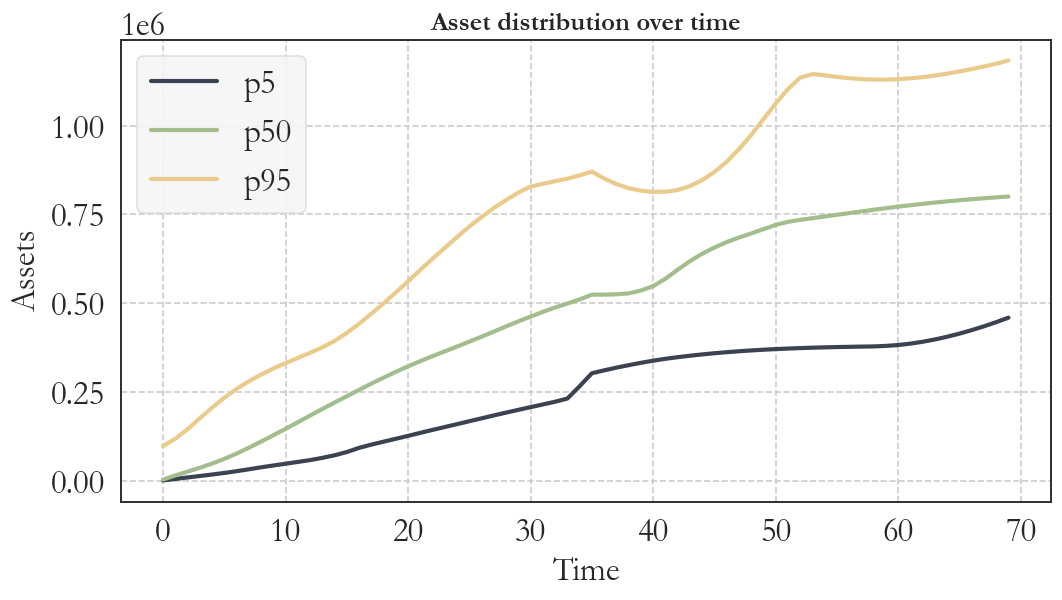

In [16]:
import numpy as np

a = model.sim.a
p5 = np.percentile(a, 5, axis=0)
p50 = np.percentile(a, 50, axis=0)
p95 = np.percentile(a, 95, axis=0)

plt.figure()
plt.plot(p5, label='p5')
plt.plot(p50, label='p50')
plt.plot(p95, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

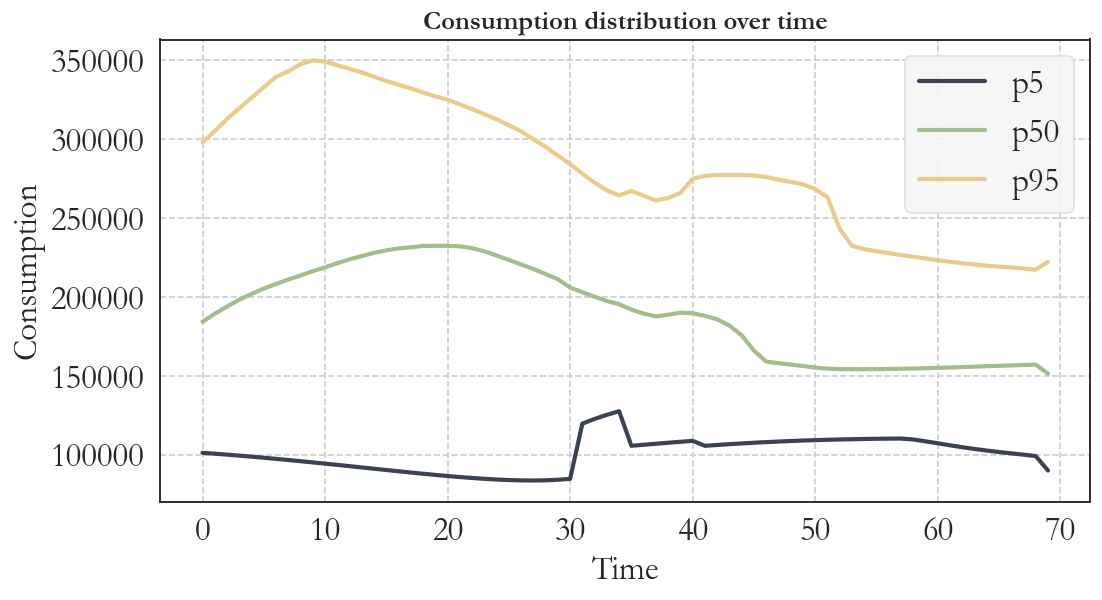

In [17]:
import numpy as np

c = model.sim.c
p5_c  = np.percentile(c, 5, axis=0)
p50_c = np.percentile(c, 50, axis=0)
p95_c = np.percentile(c, 95, axis=0)

plt.figure()
plt.plot(p5_c, label='p5')
plt.plot(p50_c, label='p50')
plt.plot(p95_c, label='p95')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.title('Consumption distribution over time')
plt.legend()
plt.show()

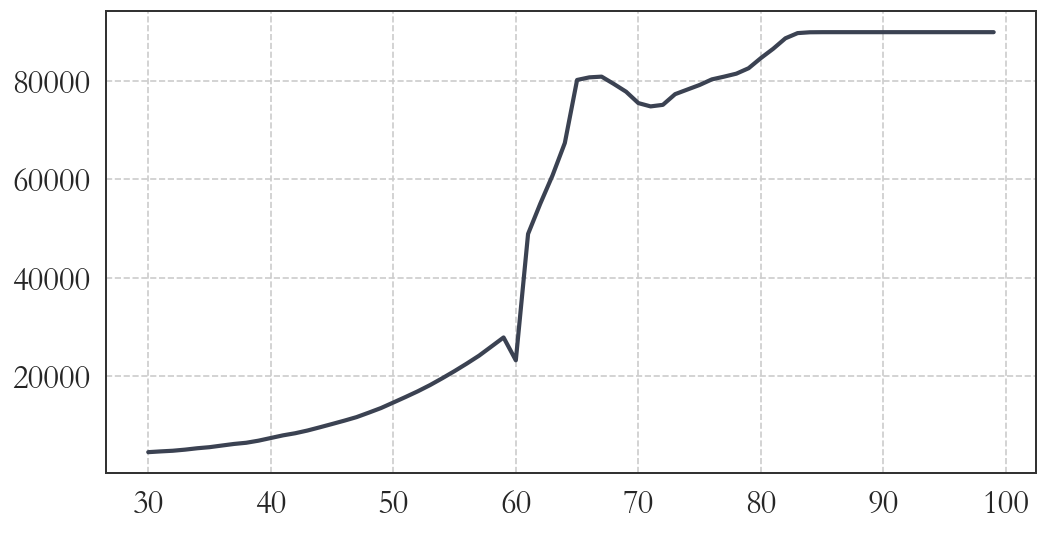

In [18]:
plt.plot(x_vals, model.sim.chi_payment.mean(axis=0), label='Simulated Chi Payment') 

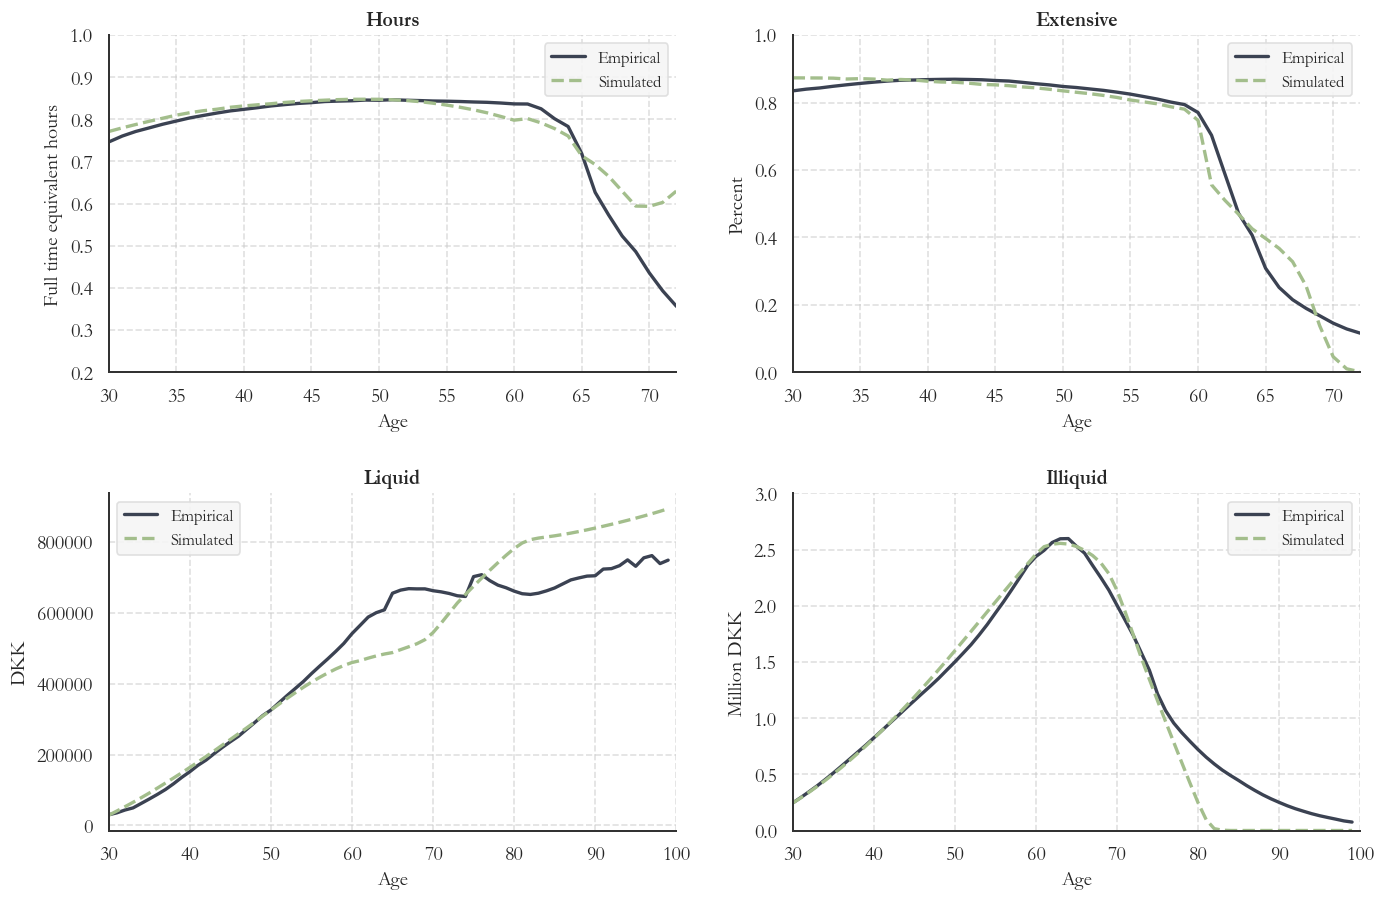

In [11]:
a_dict_new = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:43],
            moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:43],
                  moments['extensive']],
    'liquid': [np.mean(model.sim.a, axis=0),
            moments['assets']],
    'illiquid': [np.clip(np.clip(np.mean(model.sim.s, axis=0), 0, None) / 1_000_000, 0, None),
            moments['savings'] / 1_000_000]  ,
}


plot_model_vs_data_2x3(a_dict_new, title=None, save_title="2018_all_graph_slides")

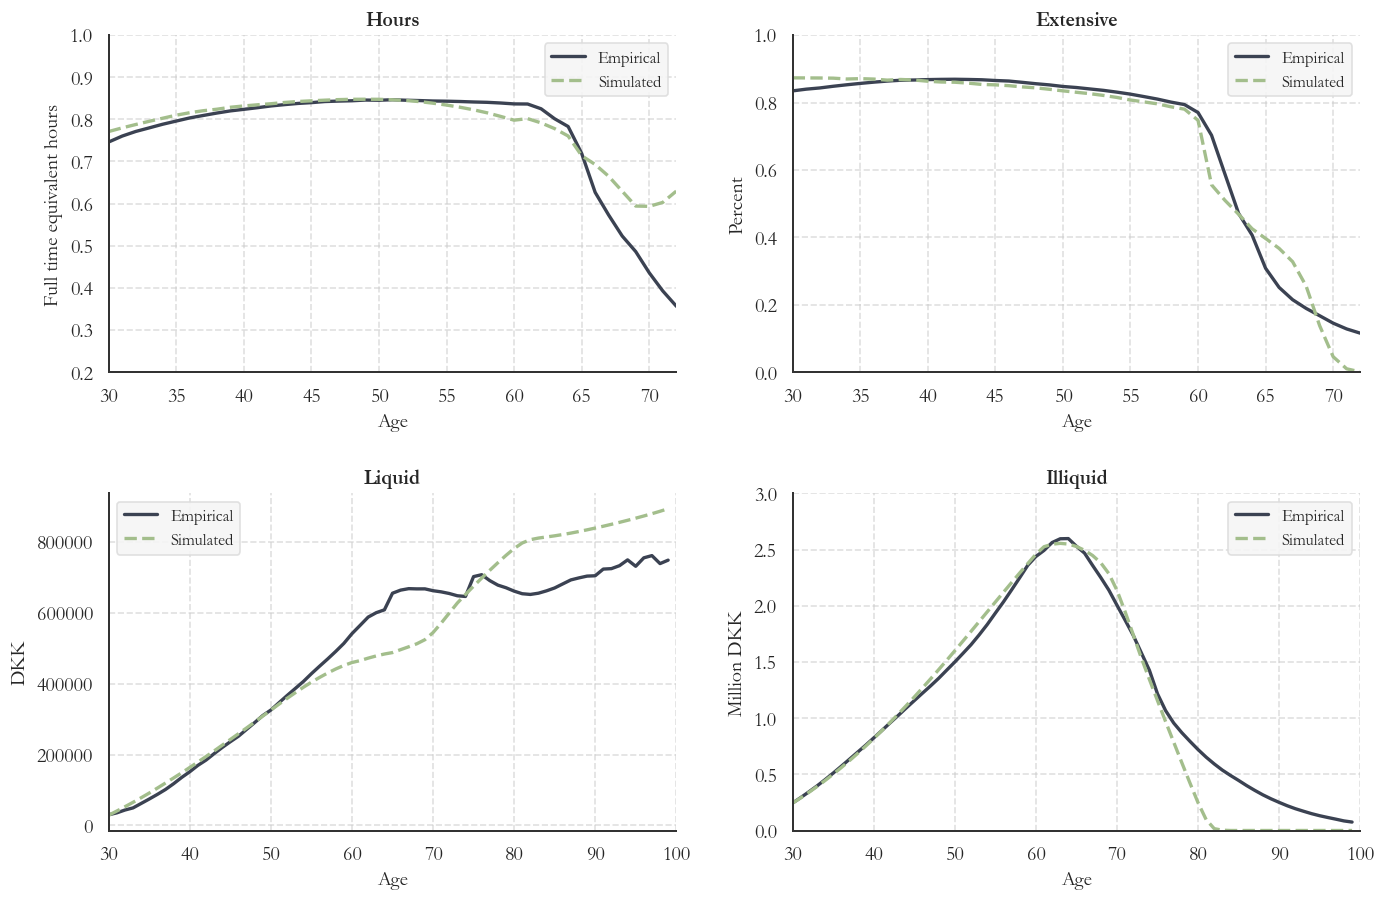

In [12]:
plot_model_vs_data_3x2(a_dict_new, title=None, save_title="oos_all_graph")

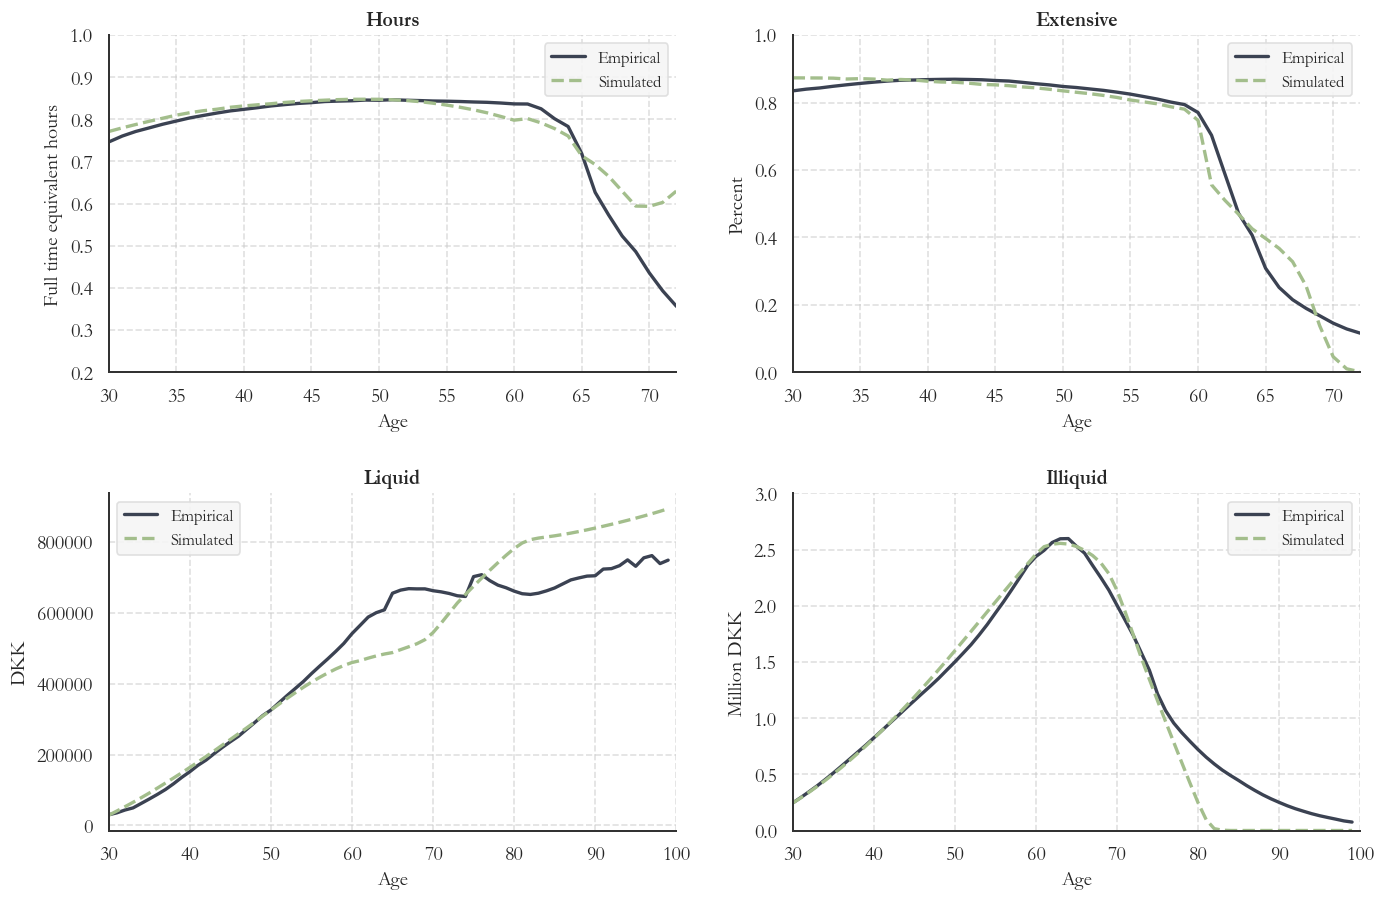

In [13]:


plot_model_vs_data_2x3(a_dict_new, title=None, save_title="oos_all_graph")